In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load the cleaned datasets
df_alcohol = pd.read_csv('../data/processed/alcohol_recoded.csv')
df_bmi = pd.read_csv('../data/processed/bmi_cleaned.csv')
df_combined = pd.read_csv('../data/processed/combined_cleaned.csv')

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

=== EDA 1: Behavior Variable (CurrentAlcoholUse) ===


,Count,Proportion
Failure (No Alcohol),6946,0.548267
Success (Alcohol),5723,0.451733


C:\Users\tunna\AppData\Local\Temp\ipykernel_12452\3434580872.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_alcohol, x='Alcohol_Binary', palette='pastel')


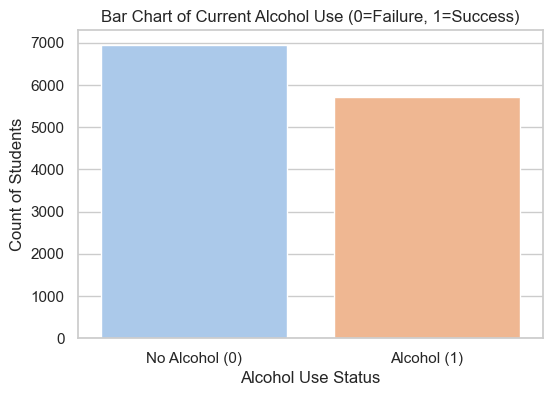

In [2]:
print("=== EDA 1: Behavior Variable (CurrentAlcoholUse) ===")

# Create summary table for Alcohol Use
alcohol_summary = df_alcohol['Alcohol_Binary'].value_counts().to_frame(name='Count')
alcohol_summary['Proportion'] = df_alcohol['Alcohol_Binary'].value_counts(normalize=True)
alcohol_summary.index = ['Failure (No Alcohol)', 'Success (Alcohol)']
display(alcohol_summary)

# Plot bar chart for Alcohol Use
plt.figure(figsize=(6, 4))
sns.countplot(data=df_alcohol, x='Alcohol_Binary', palette='pastel')
plt.title('Bar Chart of Current Alcohol Use (0=Failure, 1=Success)')
plt.xlabel('Alcohol Use Status')
plt.ylabel('Count of Students')
plt.xticks([0, 1], ['No Alcohol (0)', 'Alcohol (1)'])
plt.show()

> **Interpretation for Behavior Variable:**
> Based on the bar chart and summary table, out of the 12,669 valid responses, approximately 45.17% of students fall into the "Success" category (currently using alcohol). The number of students who do not drink (6,946) is slightly higher than those who do (5,723).


=== EDA 2: Continuous Variable (BMIPCT) ===


,count,mean,std,min,25%,50%,75%,max
BMIPCT,13062.0,64.820683,27.516756,3.720000e-09,45.16627,70.138535,89.450968,99.939213


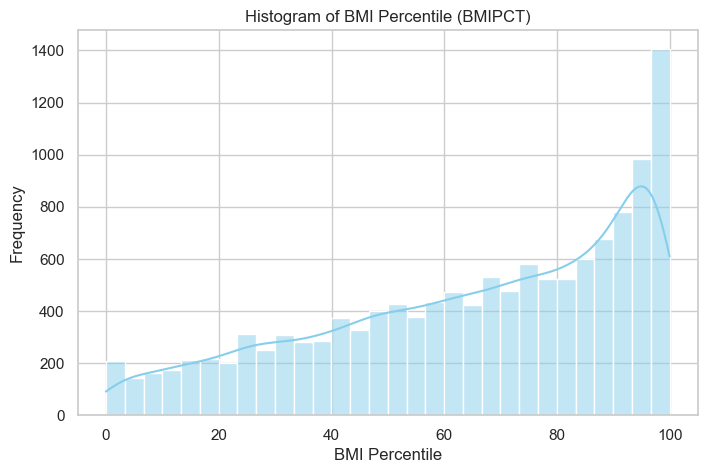

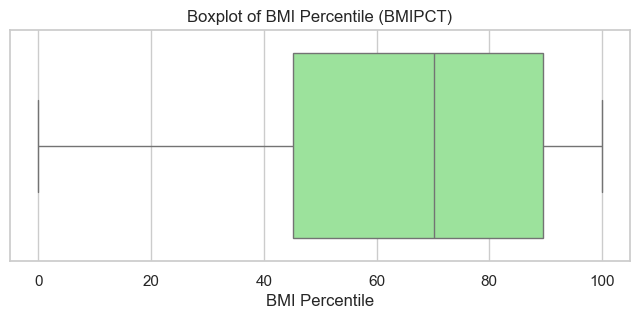

In [3]:
print("\n=== EDA 2: Continuous Variable (BMIPCT) ===")

# Create summary statistics table for BMIPCT
bmi_summary = df_bmi['BMIPCT'].describe().to_frame().T
display(bmi_summary)

# Plot histogram for BMIPCT
plt.figure(figsize=(8, 5))
sns.histplot(df_bmi['BMIPCT'], bins=30, kde=True, color='skyblue')
plt.title('Histogram of BMI Percentile (BMIPCT)')
plt.xlabel('BMI Percentile')
plt.ylabel('Frequency')
plt.show()

# Plot boxplot for BMIPCT
plt.figure(figsize=(8, 3))
sns.boxplot(x=df_bmi['BMIPCT'], color='lightgreen')
plt.title('Boxplot of BMI Percentile (BMIPCT)')
plt.xlabel('BMI Percentile')
plt.show()

> **Interpretation for Continuous Variable:**
> * **Distribution:** The histogram shows that the BMIPCT distribution is relatively flat across the middle percentiles but has notable peaks at the extreme low and high ends.
> * **Central Tendency & Spread:** The mean BMI percentile is 64.82, while the median is 69.59. The standard deviation is quite large (29.21).


=== EDA 3: Additional Exploration (BMIPCT by Alcohol Use) ===


C:\Users\tunna\AppData\Local\Temp\ipykernel_12452\1489409623.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Alcohol_Binary', y='BMIPCT', data=df_combined, palette='Set2')


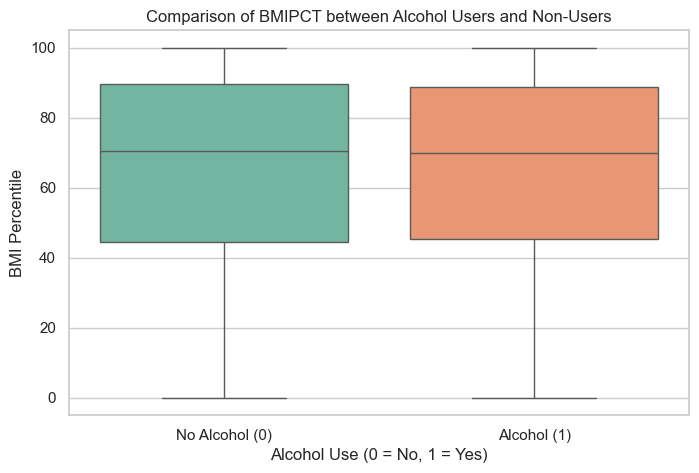


✅ Successfully saved EDA tables to ../outputs/tables/
=== Numerical Summary: BMIPCT by Alcohol Use ===


,count,mean,std,min,25%,50%,75%,max
Alcohol_Binary,,,,,,,,
0,6449.0,64.706045,27.844739,1.200000e-05,44.537013,70.319175,89.583091,99.925951
1,5394.0,64.799448,26.978167,1.930000e-07,45.373298,69.871714,88.674555,99.939213



Median BMIPCT by group:
Alcohol_Binary
0    70.319175
1    69.871714
Name: BMIPCT, dtype: float64


In [4]:
print("\n=== EDA 3: Additional Exploration (BMIPCT by Alcohol Use) ===")

# Compare BMIPCT between alcohol users and non-users
plt.figure(figsize=(8, 5))
sns.boxplot(x='Alcohol_Binary', y='BMIPCT', data=df_combined, palette='Set2')
plt.title('Comparison of BMIPCT between Alcohol Users and Non-Users')
plt.xlabel('Alcohol Use (0 = No, 1 = Yes)')
plt.ylabel('BMI Percentile')
plt.xticks([0, 1], ['No Alcohol (0)', 'Alcohol (1)'])
plt.show()

# Export tables to the outputs folder
os.makedirs('../outputs/tables', exist_ok=True)
alcohol_summary.to_csv('../outputs/tables/alcohol_eda_summary.csv')
bmi_summary.to_csv('../outputs/tables/bmi_eda_summary.csv')

print("\n✅ Successfully saved EDA tables to ../outputs/tables/")

# Calculate detailed descriptive statistics of BMIPCT grouped by Alcohol Use
print("=== Numerical Summary: BMIPCT by Alcohol Use ===")
grouped_stats = df_combined.groupby('Alcohol_Binary')['BMIPCT'].describe()
display(grouped_stats)

# Calculate and print only the median for a quick comparison
median_values = df_combined.groupby('Alcohol_Binary')['BMIPCT'].median()
print("\nMedian BMIPCT by group:")
print(median_values)

> **Interpretation for Additional Exploration:**
> By grouping the BMIPCT data by our behavior variable (Alcohol Use), the side-by-side boxplot reveals that students who **do not** use alcohol (0) tend to have a slightly higher median BMI percentile compared to those who do (1). However, the overall spread and range of BMI percentiles remain quite similar between the two groups.